# CC fit (flat LCDM)

### Import libraries

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, det, pinv
import emcee
from chainconsumer import ChainConsumer

In [2]:
dir_home = os.getcwd()
dir_data = dir_home+'/../data/'

In [3]:
print("dir_home", dir_home)
print("\ndir_data", dir_data)

dir_home c:\AMEYA\PhD\DATASETS\CC_NEW\CCcovariance\examples

dir_data c:\AMEYA\PhD\DATASETS\CC_NEW\CCcovariance\examples/../data/


### Define functions for likelihood analysis

In [4]:
def Hzmodel(params, z):
    H0, Omegam = params
    return H0*np.sqrt(Omegam*(1+z)**3+(1-Omegam))

r = 9.04e-5
def HCHMplus(params, z):
    H0, Omegam, be = params
    al = 1 - Omegam - r - 3*be
    #xi = (-1 + np.sqrt(7 - 6*m - 6*radiation)) / 3
    term_1 = Omegam*(1+z)**3 + r*(1+z)**4 + al
    sqrt_term_1 = term_1**2 + 12*be
    sqrt_term_2 = term_1 + np.sqrt(sqrt_term_1)
    return H0 * np.sqrt(sqrt_term_2 / 2)

def lnlike(p, zHz, Hz, inv_cov_matr):
    chi2=0.
    residual=Hz-HCHMplus(p, zHz)
    for i in range(0, len(zHz)):
            for j in range(0, len(zHz)):
                chi2=chi2+((residual[i])*inv_cov_matr[i,j]*(residual[j]))
    
    return -0.5 * chi2

def lnprior(p):
    H0, Omegam, beta = p
    if (50. < H0 < 90. and 0.01 < Omegam < 0.5 and -5 < beta < -1e-10):
        return -0.5 * ( (H0 - 70)/5 )**2 - 0.5 * ( (Omegam - 0.3)/0.05 )**2
    return -np.inf

r"""
def lngaussprior(p):
    H0, Omegam, beta = p
    if (50. < H0 < 100. and 0.01 < Omegam < 0.99 and -5 < beta < -0.0001):
        return -0.5 * ( (H0 - 70)/5 )**2 - 0.5 * ( (Omegam - 0.3)/0.05 )**2 - 0.5 * ( (beta + 1)/0.5 )**2
 
def lnprior(p):
    H0, Omegam = p
    if (50. < H0 < 100. and 0.01 < Omegam < 0.99 and -3.0 < w0 < 0.0 and -5.0 < wa < 5.0):
        return -0.5 * (np.sum(((Omegam-Omegam_fid)/errOmegam_fid)**2)+np.sum(((H0-H0_fid)/errH0_fid)**2))
    return -np.inf
"""

def lnprob(p, zHz, Hz, inv_cov_matr):
    lp = lnprior(p)
    return lp + lnlike(p, zHz, Hz, inv_cov_matr) if np.isfinite(lp) else -np.inf    

### Fiducial values

Here we consider some fiducial values for H$_0$ and $\Omega_{M}$ purely for comparison purposes. 

The values are not considered in the fit, but just adopted as comparison values, and can be changed accordingly to compare CC results with another set of cosmological parameters.

In [5]:
H0_fid = 67.37 
errH0_fid = 0.54
Omegam_fid = 0.308

H0_pl = H0_fid
Omegam_pl = Omegam_fid
planck=[H0_pl, Omegam_pl]

### Load data

In this example, we are fitting only the data from Moresco et al. papers. A similar analysis can be extended to the full CC compilation.

In [6]:
os.chdir(dir_data)
filename = 'HzTable_MM_BC03.dat'
z, Hz, errHz = np.genfromtxt(filename, comments='#', usecols=(0,1,2), unpack=True, delimiter=',')
ref = np.genfromtxt(filename, comments='#', usecols=(3), unpack=True, dtype=str, delimiter=',')

filename = 'data_MM20.dat'
zmod, imf, slib, sps, spsooo = np.genfromtxt(filename, comments='#', usecols=(0,1,2,3,4), unpack=True)
os.chdir(dir_home)

### Estimate CC covariance components

In [7]:
cov_mat_diag = np.zeros((len(z), len(z)), dtype='float64') 

for i in range(len(z)):
	cov_mat_diag[i,i] = errHz[i]**2

imf_intp = np.interp(z, zmod, imf)/100
slib_intp = np.interp(z, zmod, slib)/100
sps_intp = np.interp(z, zmod, sps)/100
spsooo_intp = np.interp(z, zmod, spsooo)/100

cov_mat_imf = np.zeros((len(z), len(z)), dtype='float64')
cov_mat_slib = np.zeros((len(z), len(z)), dtype='float64')
cov_mat_sps = np.zeros((len(z), len(z)), dtype='float64')
cov_mat_spsooo = np.zeros((len(z), len(z)), dtype='float64')

for i in range(len(z)):
	for j in range(len(z)):
		cov_mat_imf[i,j] = Hz[i] * imf_intp[i] * Hz[j] * imf_intp[j]
		cov_mat_slib[i,j] = Hz[i] * slib_intp[i] * Hz[j] * slib_intp[j]
		cov_mat_sps[i,j] = Hz[i] * sps_intp[i] * Hz[j] * sps_intp[j]
		cov_mat_spsooo[i,j] = Hz[i] * spsooo_intp[i] * Hz[j] * spsooo_intp[j]
        

### Estimate full CC covariance matrix, and its determinant

In [8]:
cov_mat = cov_mat_spsooo+cov_mat_imf+cov_mat_diag
inv_cov_mat = inv(cov_mat)
inv_cov_mat_diag = inv(cov_mat_diag)

(sign, logdet) = np.linalg.slogdet(cov_mat)
determinant = np.exp(logdet)

In [9]:
determinant

np.float64(4.5597910663032157e+33)

### Initialize the sampler

In [10]:
# inizialize
nwalkers=250
initial = np.array([70, 0.3, -1])
ndim = len(initial)
p0 = [np.array(initial) + 1e-3 * np.random.randn(ndim)
      for i in range(nwalkers)]

# create sampler with and without the full systematic covariance matrix
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(z,Hz,inv_cov_mat))
sampler_d = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(z,Hz,inv_cov_mat_diag))

### Running MCMC analysis

In [20]:
Nsteps=3000
p0, _, _ = sampler.run_mcmc(p0, Nsteps, progress=True)
#p0, _, _ = sampler_d.run_mcmc(p0, Nsteps, progress=True)

# Discarding burn-in
burnin = Nsteps // 3
thin = 1
samples = sampler.get_chain(discard=burnin, flat=True, thin=thin)
log_prob = sampler.get_log_prob(discard=burnin, flat=True)
#samples_d = sampler_d.get_chain(discard=burnin, flat=True, thin=thin)

100%|██████████| 3000/3000 [00:56<00:00, 53.27it/s]


### Compute best-fit parameters

In [15]:
from getdist import MCSamples, plots

Removed no burn in
15
Minimum Chi^2 :  {np.float64(-3.1324304884512553)}
AIC:  2.8675695115487447
BIC:  4.991720114855374
Reduced Chi^2:  -0.2610358740376046
DIC:  8.81515422782446


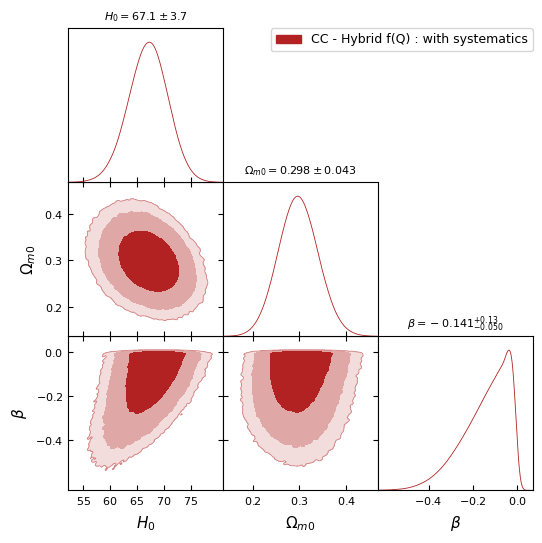

In [21]:
names = ['H0', 'Omegam0', 'beta']
latex = [r"H_0", r"\Omega_{m0}", r"\beta"]
gd = MCSamples(samples=samples, names=names, labels=latex)

best_idx = int(np.argmax(log_prob))
best_theta = samples[best_idx]

#lnlike = lnlike(model_dict)
#delta = qty_ddtb - BAO_vector(best_theta, model_dict)
min_chi2 = lnlike(best_theta, z, Hz, inv_cov_mat)

aic = min_chi2 + 2 * ndim
bic = min_chi2 + ndim * np.log(len(z))
redchi2 = min_chi2 / (len(z) - ndim)

lnlikes_chain = np.array([lnlike(th, z, Hz, inv_cov_mat) for th in samples])  # ln L(θ) over post-burn-in samples
D_theta = -2.0 * lnlikes_chain
D_bar = np.mean(D_theta)
theta_mean = np.mean(samples, axis=0)                     # posterior mean of parameters
D_hat = -2.0 * lnlike(theta_mean, z, Hz, inv_cov_mat)
DIC = 2.0 * D_bar - D_hat
#gd_d = MCSamples(samples=samples_d, names=names, labels=latex)

print(len(z))
print(f"Minimum Chi^2 : ", {min_chi2})
print(f"AIC: ", aic)
print(f"BIC: ", bic)
print(f"Reduced Chi^2: ", redchi2)
print(f"DIC: ", DIC)

g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 3
g.triangle_plot([gd], filled=True, contour_colors=["firebrick"], title_limit=1,
                    legend_labels=[f"CC - Hybrid f(Q) : with systematics"])
plt.show()

In [92]:
import arviz as az

print("Gelman-Rubin R̂ values:")
idata = az.from_emcee(sampler)
try:
    rhat = az.rhat(idata)
    for var, val in rhat.items():
        print(f"{var}: {float(val):.4f}")
except Exception as e:
    print("R̂ computation failed:", e)

Gelman-Rubin R̂ values:
var_0: 1.0440
var_1: 1.0396
var_2: 1.0439


In [ ]:
H0_mcmc, Omegam_mcmc, beta_mcmc = map(lambda v: (v[1], v[2]-v[1], v[1]-v[0]),
                             zip(*np.percentile(samples_d, [16, 50, 84],
                                                axis=0)))
print("MCMC result 1 sigma - without systematics:")
print("""    H0 = {0[0]:.3f} +{0[1]:.3f} -{0[2]:.3f} (planck18: {1:.3f})
    Omegam = {2[0]:.3f} +{2[1]:.3f} -{2[2]:.3f} (planck18: {3:.3f})
      bets = {}""".format(H0_mcmc, H0_pl, Omegam_mcmc, Omegam_pl))

H0_mcmc, Omegam_mcmc = map(lambda v: (v[1], v[2]-v[1], v[1]-v[0]),
                             zip(*np.percentile(samples, [16, 50, 84],
                                                axis=0)))

print("MCMC result 1 sigma - with systematics:")
print("""    H0 = {0[0]:.3f} +{0[1]:.3f} -{0[2]:.3f} (planck18: {1:.3f})
    Omegam = {2[0]:.3f} +{2[1]:.3f} -{2[2]:.3f} (planck18: {3:.3f})""".format(H0_mcmc, H0_pl, Omegam_mcmc, Omegam_pl))

ValueError: too many values to unpack (expected 2)

### Initialize Chainconsumer

In [13]:
c = ChainConsumer()

c = ChainConsumer().add_chain(samples, parameters=[r"$H_0$", r"$\Omega_m$"], name="w/ syst").add_chain(samples_d, name="w/o syst")
c.configure(colors=["#900C3F", "#027800"], shade=True, shade_alpha=0.2, bar_shade=True, statistics='cumulative')

TypeError: ChainConsumer.add_chain() got an unexpected keyword argument 'parameters'

### Plot contours

Current constraints (for a f$\Lambda$CDM model) <ins>considering Moresco et al. CC data alone</ins> give:
- H$_0 = 66.2^{+3.8}_{-3.9}$ km/s/Mpc **without considering systematics** due to SPS models;
- H$_0 = 66^{+5.5}_{-5.6}$ km/s/Mpc **considering the full systematics**.

In these plots, with the option *thruth=list* it is possible to show as dashed lines some reference values (chosen arbitrarily above at the Planck18 values) purely for a comparison purpose.

In [14]:
_=c.plotter.plot(figsize="column", truth=planck)

TypeError: Plotter.plot() got an unexpected keyword argument 'truth'

### Plot steps and distributions

In these plots, with the option *thruth=list* it is possible to show as dashed lines some reference values (chosen arbitrarily above at the Planck18 values) purely for a comparison purpose.

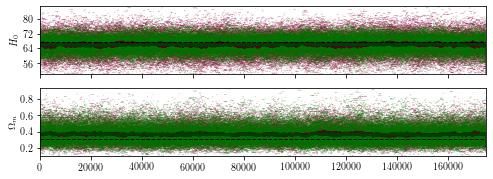

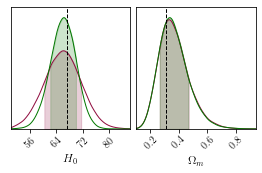

In [13]:
_=c.plotter.plot_walks(truth=planck, convolve=100)
_=c.plotter.plot_distributions(truth=planck)